In [3]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from importlib import reload
from scipy.stats import levy
from scipy.stats import invgauss

import core.simulator, core.geometry, core.membrane, core.concentration, core.registry, core.analysis, core.transporter, core.ficks
reload(core.simulator)
reload(core.geometry)
reload(core.membrane)
reload(core.concentration)
reload(core.registry)
reload(core.analysis)
reload(core.transporter)
reload(core.ficks)

from core.simulator import Simulator
from core.geometry import BoxGeometry, WallConfig
from core.membrane import Membrane
from core.concentration import ConcentrationField, FirstPassageTracker
from core.registry import Registry
from core.ficks import FicksSolver
from core.analysis import summarise, print_summary
from core.transporter import ActiveTransporter, TransporterParams
print("Imports ok 👍")

Imports ok 👍



Running ensemble (3 runs × 250000 steps)...
Ensemble MSD collected.

Running main simulation...
Done.
  Particles arrived at threshold: 309
  Absorbed at z_hi:  309
  Active particles remaining:     191
z_start: 0.00049
z_hi (threshold): 0.0005
Distance: 1.0000000000000026e-05
Bounds: [[-0.0005  0.0005]
 [-0.0005  0.0005]
 [-0.0005  0.0005]]
Final z positions (sample): [5.00000000e-04 5.00000000e-04 5.00000000e-04 5.00000000e-04
 5.00000000e-04 1.31376876e-05 1.05236744e-04 5.00000000e-04
 2.77014367e-04 5.00000000e-04]
Particles at z_hi: 309
Active mask: 191
FPT tracker dict: {np.int64(299): 192, np.int64(345): 219, np.int64(363): 274, np.int64(251): 306, np.int64(463): 316, np.int64(185): 323, np.int64(150): 325, np.int64(154): 331, np.int64(357): 362, np.int64(219): 370, np.int64(320): 412, np.int64(131): 463, np.int64(406): 474, np.int64(4): 477, np.int64(105): 482, np.int64(272): 500, np.int64(392): 512, np.int64(231): 515, np.int64(232): 522, np.int64(192): 525, np.int64(23): 53

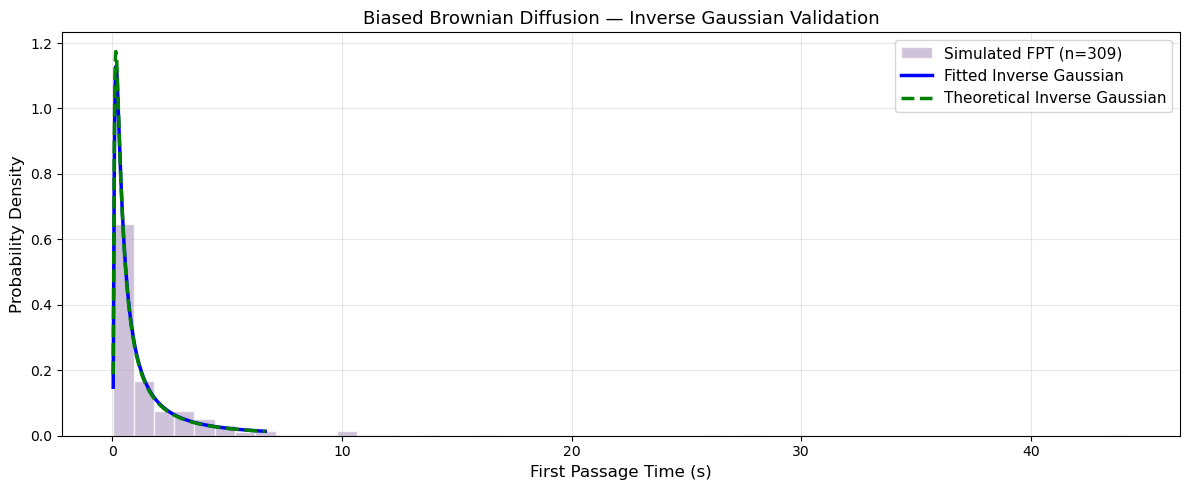


Sample mean FPT: 1.987439 s
Theory mean FPT: 2.000000 s
Fitted mu: 1.987439 s
Theory lam: 0.500000
Fitted lam: 0.526716
KS p-value: 0.6685
yayayayy Inverse Gaussian confirmed 


In [28]:
N_STEPS = 250000
N_ENSEMBLE = 3
N_PARTICLES = 500
DT = 2.5e-4
D = 1e-10
v = 5e-6

z_start = 4.9e-4
box_size = 1e-3
walls = {
    'x_lo': WallConfig(mode='reflect'),
    'x_hi': WallConfig(mode='reflect'),
    'y_lo': WallConfig(mode='reflect'),
    'y_hi': WallConfig(mode='reflect'),
    'z_lo': WallConfig(mode='reflect'),  
    'z_hi': WallConfig(mode='absorb')
}
half = box_size / 2
bounds = [(-half,half), (-half,half), (-half,half)]
box = BoxGeometry( bounds=bounds,walls=walls)

params = TransporterParams(
    name="test_transporter",
    gene="ABCB1",
    direction="efflux",
    axis=2,
    Vmax_ms=v,
    Km_um=1e-9,
    particles_per_mole=1.0
)
trnsp = ActiveTransporter(
    params=params,
    membrane_position = 0.0,
    membrane_side = "left",
    D_eff=D,
    dt=DT
)
fpt_tracker = FirstPassageTracker(
    axis = 2,
    threshold = box_size/2, #5e-4
    dt=DT,
    n_particles=N_PARTICLES
)
sim = Simulator(
    n_particles = N_PARTICLES,D=D,dt=DT,
    geometry= box,
    membrane = None,
    concentration_field = None, fpt_tracker = fpt_tracker,
    transporters = [trnsp]
)

print(f"\nRunning ensemble ({N_ENSEMBLE} runs × {N_STEPS} steps)...")
msd_result = sim.run_ensemble(n_steps=N_STEPS, n_runs=N_ENSEMBLE, seed_position=z_start)
print("Ensemble MSD collected.")

print("\nRunning main simulation...")
sim.reset()
sim.seed_at_z(z_start)   #particles start nearer to z_hi=5e-4
sim.run(n_steps=N_STEPS)

print(f"Done.")
print(f"  Particles arrived at threshold: {len(fpt_tracker.fpt)}")
print(f"  Absorbed at z_hi:  {box.n_absorbed['z_hi']}")
print(f"  Active particles remaining:     {box.active_mask.sum()}")
print(f"z_start: {z_start}")
print(f"z_hi (threshold): {box_size/2}")
print(f"Distance: {box_size/2 - z_start}")
print(f"Bounds: {box.bounds}")
final_z = sim.positions[:, 2]
print(f"Final z positions (sample): {final_z[:10]}")
print(f"Particles at z_hi: {(final_z >= 0.0005).sum()}")
print(f"Active mask: {sim.geometry.active_mask.sum()}")
print(f"FPT tracker dict: {fpt_tracker.fpt}")
print(f"FPT tracker already_crossed: {fpt_tracker._already_crossed}")

step1 = np.abs(np.array(sim.history[1]) - np.array(sim.history[0]))
print(f"\nMean step size:    {step1.mean()*1e9:.4f} nm")
print(f"Expected sigma:    {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Ratio:             {step1.mean() / np.sqrt(2*D*DT):.4f}  (expect ~0.80)")

from scipy.stats import invgauss
import matplotlib.pyplot as plt

fpt_list = np.array(list(fpt_tracker.fpt.values())) * DT

d = 5e-4 - z_start
mu_theory_redner = d / v
lam_theory_redner = d**2 / (2*D)

mu_theory_scipy = mu_theory_redner / lam_theory_redner
scale_theory = lam_theory_redner

mu_scipy, loc, scale = invgauss.fit(fpt_list, floc=0)
mu_fit = mu_scipy * scale
lam_fit = scale

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fpt_list, bins=50, density=True, alpha=0.7, color='#b8a9c9', 
        edgecolor='white', label=f'Simulated FPT (n={len(fpt_list)})')

x = np.linspace(fpt_list.min(), np.percentile(fpt_list, 95), 300)
ax.plot(x, invgauss.pdf(x, mu_scipy, loc=0, scale=scale), 'b-', lw=2.5, label='Fitted Inverse Gaussian')
ax.plot(x, invgauss.pdf(x, mu_theory_scipy, loc=0, scale=scale_theory), 'g--', lw=2.5, label='Theoretical Inverse Gaussian')

ax.set_xlabel('First Passage Time (s)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Biased Brownian Diffusion — Inverse Gaussian Validation', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ks_stat, pval = stats.kstest(fpt_list, lambda t: invgauss.cdf(t, mu_theory_scipy, loc=0, scale=scale_theory))

print(f"\nSample mean FPT: {np.mean(fpt_list):.6f} s")
print(f"Theory mean FPT: {mu_theory_redner:.6f} s")
print(f"Fitted mu: {mu_fit:.6f} s")
print(f"Theory lam: {lam_theory_redner:.6f}")
print(f"Fitted lam: {lam_fit:.6f}")
print(f"KS p-value: {pval:.4f}")
print(f"yayayayy Inverse Gaussian confirmed " if pval > 0.05 else f"bruhh Mismatch")

In [29]:
print(trnsp.get_stats())


{'n_steps_applied': 250000, 'mean_drift_per_step': 1.2499999999987504e-09, 'max_drift_per_step': 1.2499999999987504e-09, 'total_drift': 0.15625000000046801, 'activity_zone_m': np.float64(2.2360679774997896e-07)}



Running ensemble (3 runs × 250000 steps)...
Ensemble MSD collected.

Running main simulation...
Done.
  Particles arrived at threshold: 471
  Absorbed at z_hi:  471
  Active particles remaining:     529
z_start: 0.000485
z_hi (threshold): 0.0005
Distance: 1.4999999999999985e-05
Bounds: [[-0.0005  0.0005]
 [-0.0005  0.0005]
 [-0.0005  0.0005]]
Final z positions (sample): [2.43941469e-04 5.00000000e-04 5.00000000e-04 1.37018736e-04
 5.00000000e-04 5.00000000e-04 2.84168985e-05 4.29114109e-05
 5.00000000e-04 4.94941597e-05]
Particles at z_hi: 471
Active mask: 529
FPT tracker dict: {np.int64(241): 354, np.int64(285): 406, np.int64(785): 460, np.int64(32): 461, np.int64(259): 482, np.int64(645): 530, np.int64(79): 543, np.int64(615): 549, np.int64(912): 671, np.int64(419): 686, np.int64(637): 703, np.int64(842): 771, np.int64(167): 781, np.int64(333): 818, np.int64(315): 823, np.int64(752): 828, np.int64(633): 871, np.int64(717): 891, np.int64(526): 924, np.int64(868): 938, np.int64(207): 

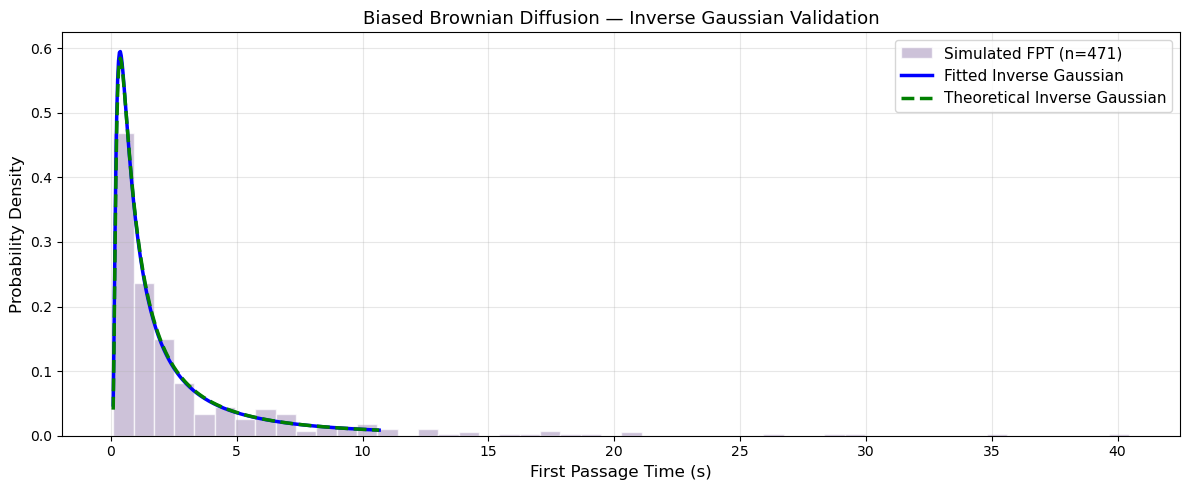


Sample mean FPT: 3.028296 s
Theory mean FPT: 3.000000 s
Fitted mu: 3.028296 s
Theory lam: 1.125000
Fitted lam: 1.089894
KS p-value: 0.7990
yayayayy Inverse Gaussian confirmed 


In [3]:
N_STEPS = 250000
N_ENSEMBLE = 3
N_PARTICLES = 1000
DT = 2.5e-4
D = 1e-10
v = 5e-6

z_start = 4.85e-4
box_size = 1e-3
walls = {
    'x_lo': WallConfig(mode='reflect'),
    'x_hi': WallConfig(mode='reflect'),
    'y_lo': WallConfig(mode='reflect'),
    'y_hi': WallConfig(mode='reflect'),
    'z_lo': WallConfig(mode='reflect'),  
    'z_hi': WallConfig(mode='absorb')
}
half = box_size / 2
bounds = [(-half,half), (-half,half), (-half,half)]
box = BoxGeometry( bounds=bounds,walls=walls)

params = TransporterParams(
    name="test_transporter",
    gene="ABCB1",
    direction="efflux",
    axis=2,
    Vmax_ms=v,
    Km_um=1e-9,
    particles_per_mole=1.0
)
trnsp = ActiveTransporter(
    params=params,
    membrane_position = 0.0,
    membrane_side = "left",
    D_eff=D,
    dt=DT
)
fpt_tracker = FirstPassageTracker(
    axis = 2,
    threshold = box_size/2, #5e-4
    dt=DT,
    n_particles=N_PARTICLES
)
sim = Simulator(
    n_particles = N_PARTICLES,D=D,dt=DT,
    geometry= box,
    membrane = None,
    concentration_field = None, fpt_tracker = fpt_tracker,
    transporters = [trnsp]
)

print(f"\nRunning ensemble ({N_ENSEMBLE} runs × {N_STEPS} steps)...")
msd_result = sim.run_ensemble(n_steps=N_STEPS, n_runs=N_ENSEMBLE, seed_position=z_start)
print("Ensemble MSD collected.")

print("\nRunning main simulation...")
sim.reset()
sim.seed_at_z(z_start)   #particles start nearer to z_hi=5e-4
sim.run(n_steps=N_STEPS)

print(f"Done.")
print(f"  Particles arrived at threshold: {len(fpt_tracker.fpt)}")
print(f"  Absorbed at z_hi:  {box.n_absorbed['z_hi']}")
print(f"  Active particles remaining:     {box.active_mask.sum()}")
print(f"z_start: {z_start}")
print(f"z_hi (threshold): {box_size/2}")
print(f"Distance: {box_size/2 - z_start}")
print(f"Bounds: {box.bounds}")
final_z = sim.positions[:, 2]
print(f"Final z positions (sample): {final_z[:10]}")
print(f"Particles at z_hi: {(final_z >= 0.0005).sum()}")
print(f"Active mask: {sim.geometry.active_mask.sum()}")
print(f"FPT tracker dict: {fpt_tracker.fpt}")
print(f"FPT tracker already_crossed: {fpt_tracker._already_crossed}")

step1 = np.abs(np.array(sim.history[1]) - np.array(sim.history[0]))
print(f"\nMean step size:    {step1.mean()*1e9:.4f} nm")
print(f"Expected sigma:    {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Ratio:             {step1.mean() / np.sqrt(2*D*DT):.4f}  (expect ~0.80)")

from scipy.stats import invgauss
import matplotlib.pyplot as plt

fpt_list = np.array(list(fpt_tracker.fpt.values())) * DT

d = 5e-4 - z_start
mu_theory_redner = d / v
lam_theory_redner = d**2 / (2*D)

mu_theory_scipy = mu_theory_redner / lam_theory_redner
scale_theory = lam_theory_redner

mu_scipy, loc, scale = invgauss.fit(fpt_list, floc=0)
mu_fit = mu_scipy * scale
lam_fit = scale

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fpt_list, bins=50, density=True, alpha=0.7, color='#b8a9c9', 
        edgecolor='white', label=f'Simulated FPT (n={len(fpt_list)})')

x = np.linspace(fpt_list.min(), np.percentile(fpt_list, 95), 300)
ax.plot(x, invgauss.pdf(x, mu_scipy, loc=0, scale=scale), 'b-', lw=2.5, label='Fitted Inverse Gaussian')
ax.plot(x, invgauss.pdf(x, mu_theory_scipy, loc=0, scale=scale_theory), 'g--', lw=2.5, label='Theoretical Inverse Gaussian')

ax.set_xlabel('First Passage Time (s)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Biased Brownian Diffusion — Inverse Gaussian Validation', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ks_stat, pval = stats.kstest(fpt_list, lambda t: invgauss.cdf(t, mu_theory_scipy, loc=0, scale=scale_theory))

print(f"\nSample mean FPT: {np.mean(fpt_list):.6f} s")
print(f"Theory mean FPT: {mu_theory_redner:.6f} s")
print(f"Fitted mu: {mu_fit:.6f} s")
print(f"Theory lam: {lam_theory_redner:.6f}")
print(f"Fitted lam: {lam_fit:.6f}")
print(f"KS p-value: {pval:.4f}")
print(f"yayayayy Inverse Gaussian confirmed " if pval > 0.05 else f"bruhh Mismatch")


Running ensemble (3 runs × 1000000 steps)...
Ensemble MSD collected.

Running main simulation...
Done.
  Particles arrived at threshold: 484
  Absorbed at z_hi:  484
  Active particles remaining:     16
z_start: 0.000489
z_hi (threshold): 0.0005
Distance: 1.100000000000005e-05
Bounds: [[-0.0005  0.0005]
 [-0.0005  0.0005]
 [-0.0005  0.0005]]
Final z positions (sample): [0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0005]
Particles at z_hi: 484
Active mask: 16
FPT tracker dict: {np.int64(441): 314, np.int64(326): 344, np.int64(232): 378, np.int64(220): 397, np.int64(410): 412, np.int64(192): 414, np.int64(113): 446, np.int64(52): 469, np.int64(310): 485, np.int64(414): 505, np.int64(408): 508, np.int64(87): 520, np.int64(51): 533, np.int64(100): 537, np.int64(65): 562, np.int64(318): 575, np.int64(178): 581, np.int64(70): 590, np.int64(462): 594, np.int64(473): 615, np.int64(61): 630, np.int64(171): 630, np.int64(115): 635, np.int64(45): 636, np.int64(249): 669, np.i

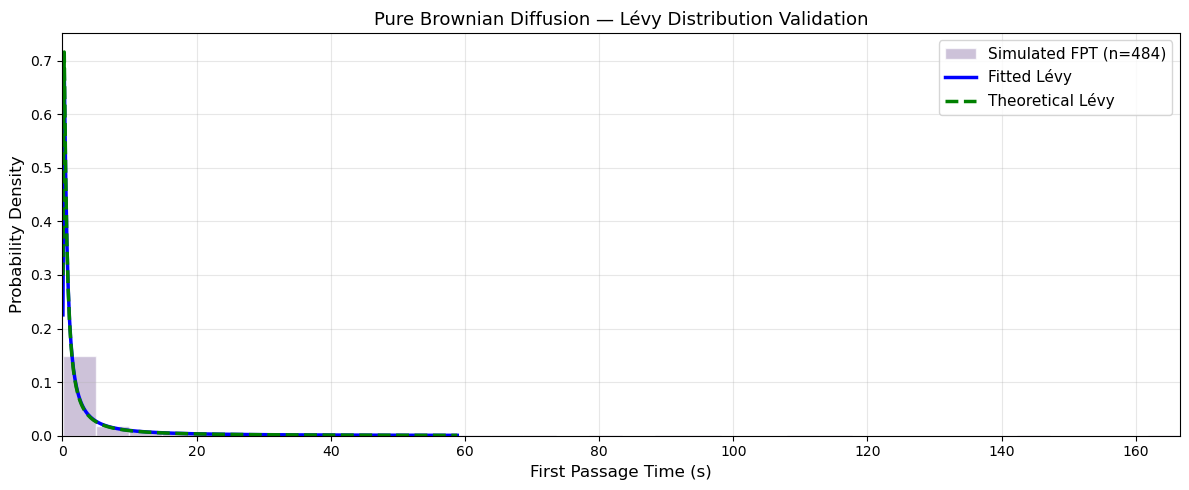


Theory c parameter: 0.605000
Fitted scale: 0.655664
KS p-value: 0.3053
yayayayy Lévy confirmed


In [2]:
N_STEPS = 1000000
N_ENSEMBLE = 3
N_PARTICLES = 500
DT = 2.5e-4
D = 1e-10
v = 0

z_start = 4.89e-4
box_size = 1e-3
walls = {
    'x_lo': WallConfig(mode='reflect'),
    'x_hi': WallConfig(mode='reflect'),
    'y_lo': WallConfig(mode='reflect'),
    'y_hi': WallConfig(mode='reflect'),
    'z_lo': WallConfig(mode='reflect'),  
    'z_hi': WallConfig(mode='absorb')
}
half = box_size / 2
bounds = [(-half,half), (-half,half), (-half,half)]
box = BoxGeometry( bounds=bounds,walls=walls)

fpt_tracker = FirstPassageTracker(
    axis = 2,
    threshold = box_size/2, #5e-4
    dt=DT,
    n_particles=N_PARTICLES
)
sim = Simulator(
    n_particles = N_PARTICLES,D=D,dt=DT,
    geometry= box,
    membrane = None,
    concentration_field = None, fpt_tracker = fpt_tracker,
    transporters = []
)

print(f"\nRunning ensemble ({N_ENSEMBLE} runs × {N_STEPS} steps)...")
msd_result = sim.run_ensemble(n_steps=N_STEPS, n_runs=N_ENSEMBLE, seed_position=z_start)
print("Ensemble MSD collected.")

print("\nRunning main simulation...")
sim.reset()
sim.seed_at_z(z_start)   #particles start nearer to z_hi=5e-4
sim.run(n_steps=N_STEPS)

print(f"Done.")
print(f"  Particles arrived at threshold: {len(fpt_tracker.fpt)}")
print(f"  Absorbed at z_hi:  {box.n_absorbed['z_hi']}")
print(f"  Active particles remaining:     {box.active_mask.sum()}")
print(f"z_start: {z_start}")
print(f"z_hi (threshold): {box_size/2}")
print(f"Distance: {box_size/2 - z_start}")
print(f"Bounds: {box.bounds}")
final_z = sim.positions[:, 2]
print(f"Final z positions (sample): {final_z[:10]}")
print(f"Particles at z_hi: {(final_z >= 0.0005).sum()}")
print(f"Active mask: {sim.geometry.active_mask.sum()}")
print(f"FPT tracker dict: {fpt_tracker.fpt}")
print(f"FPT tracker already_crossed: {fpt_tracker._already_crossed}")

step1 = np.abs(np.array(sim.history[1]) - np.array(sim.history[0]))
print(f"\nMean step size:    {step1.mean()*1e9:.4f} nm")
print(f"Expected sigma:    {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Ratio:             {step1.mean() / np.sqrt(2*D*DT):.4f}  (expect ~0.80)")

fpt_list = np.array(list(fpt_tracker.fpt.values())) * DT

d = 5e-4 - z_start
c_theory = d**2 / (2*D)

params = levy.fit(fpt_list, floc=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fpt_list, bins=50, density=True, alpha=0.7, color='#b8a9c9', 
        edgecolor='white', label=f'Simulated FPT (n={len(fpt_list)})')

x = np.linspace(fpt_list.min(), np.percentile(fpt_list, 95), 300)
ax.plot(x, levy.pdf(x, *params), 'b-', lw=2.5, label='Fitted Lévy')
ax.plot(x, levy.pdf(x, loc=0, scale=c_theory), 'g--', lw=2.5, label='Theoretical Lévy')

ax.set_xlabel('First Passage Time (s)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Pure Brownian Diffusion — Lévy Distribution Validation', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, np.percentile(fpt_list, 99))
plt.tight_layout()
plt.show()

ks_stat, pval = stats.kstest(fpt_list, lambda t: levy.cdf(t, loc=0, scale=c_theory))

print(f"\nTheory c parameter: {c_theory:.6f}")
print(f"Fitted scale: {params[1]:.6f}")
print(f"KS p-value: {pval:.4f}")
print(f"yayayayy Lévy confirmed" if pval > 0.05 else f"bruhh Mismatch")


Running ensemble (3 runs × 500000 steps)...
Ensemble MSD collected.

Running main simulation...
Done.
  Particles arrived at threshold: 273
  Absorbed at z_hi:  273
  Active particles remaining:     727
z_start: 0.000475
z_hi (threshold): 0.0005
Distance: 2.500000000000001e-05
Bounds: [[-0.0005  0.0005]
 [-0.0005  0.0005]
 [-0.0005  0.0005]]

Mean step size:    180.0828 nm
Expected sigma:    223.6068 nm
Ratio:             0.8054  (expect ~0.80)


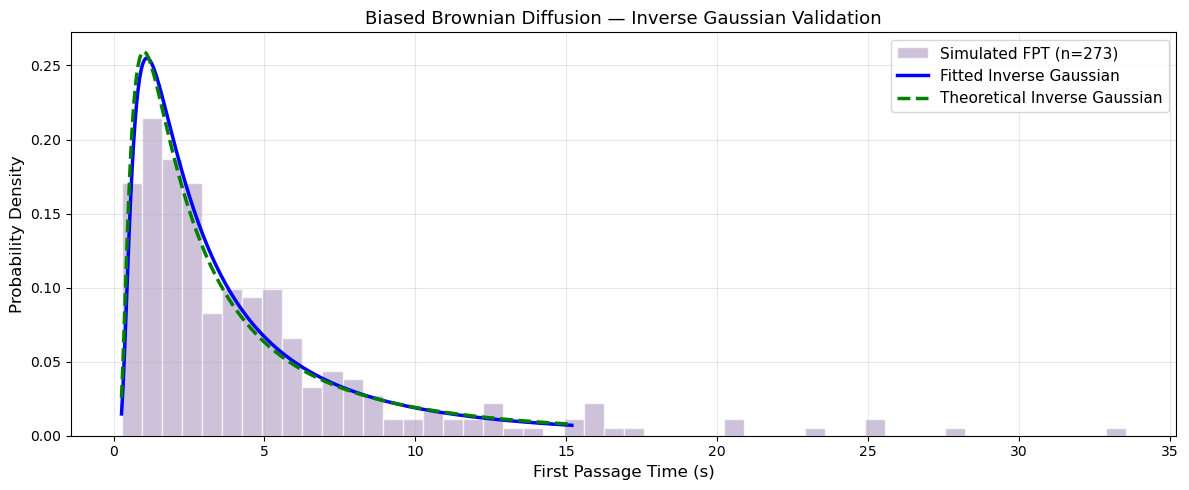


Sample mean FPT: 4.666181 s
Theory mean FPT: 5.000000 s
Fitted mu: 4.666181 s
Theory lam: 3.125000
Fitted lam: 3.512552
KS p-value: 0.5425
yayayayy Inverse Gaussian confirmed 


In [6]:
N_STEPS = 500000
N_ENSEMBLE = 3
N_PARTICLES = 1000
DT = 2.5e-4
D = 1e-10
v = 5e-6

z_start = 4.75e-4
box_size = 1e-3
walls = {
    'x_lo': WallConfig(mode='reflect'),
    'x_hi': WallConfig(mode='reflect'),
    'y_lo': WallConfig(mode='reflect'),
    'y_hi': WallConfig(mode='reflect'),
    'z_lo': WallConfig(mode='reflect'),  
    'z_hi': WallConfig(mode='absorb')
}
half = box_size / 2
bounds = [(-half,half), (-half,half), (-half,half)]
box = BoxGeometry( bounds=bounds,walls=walls)

params = TransporterParams(
    name="test_transporter",
    gene="ABCB1",
    direction="efflux",
    axis=2,
    Vmax_ms=v,
    Km_um=1e-9,
    particles_per_mole=1.0
)
trnsp = ActiveTransporter(
    params=params,
    membrane_position = 0.0,
    membrane_side = "left",
    D_eff=D,
    dt=DT
)
fpt_tracker = FirstPassageTracker(
    axis = 2,
    threshold = box_size/2, #5e-4
    dt=DT,
    n_particles=N_PARTICLES
)
sim = Simulator(
    n_particles = N_PARTICLES,D=D,dt=DT,
    geometry= box,
    membrane = None,
    concentration_field = None, fpt_tracker = fpt_tracker,
    transporters = [trnsp]
)

print(f"\nRunning ensemble ({N_ENSEMBLE} runs × {N_STEPS} steps)...")
msd_result = sim.run_ensemble(n_steps=N_STEPS, n_runs=N_ENSEMBLE, seed_position=z_start)
print("Ensemble MSD collected.")

print("\nRunning main simulation...")
sim.reset()
sim.seed_at_z(z_start)   #particles start nearer to z_hi=5e-4
sim.run(n_steps=N_STEPS)

print(f"Done.")
print(f"  Particles arrived at threshold: {len(fpt_tracker.fpt)}")
print(f"  Absorbed at z_hi:  {box.n_absorbed['z_hi']}")
print(f"  Active particles remaining:     {box.active_mask.sum()}")
print(f"z_start: {z_start}")
print(f"z_hi (threshold): {box_size/2}")
print(f"Distance: {box_size/2 - z_start}")
print(f"Bounds: {box.bounds}")
step1 = np.abs(np.array(sim.history[1]) - np.array(sim.history[0]))
print(f"\nMean step size:    {step1.mean()*1e9:.4f} nm")
print(f"Expected sigma:    {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Ratio:             {step1.mean() / np.sqrt(2*D*DT):.4f}  (expect ~0.80)")

fpt_list = np.array(list(fpt_tracker.fpt.values())) * DT

d = 5e-4 - z_start
mu_theory_redner = d / v
lam_theory_redner = d**2 / (2*D)

mu_theory_scipy = mu_theory_redner / lam_theory_redner
scale_theory = lam_theory_redner

mu_scipy, loc, scale = invgauss.fit(fpt_list, floc=0)
mu_fit = mu_scipy * scale
lam_fit = scale

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fpt_list, bins=50, density=True, alpha=0.7, color='#b8a9c9', 
        edgecolor='white', label=f'Simulated FPT (n={len(fpt_list)})')

x = np.linspace(fpt_list.min(), np.percentile(fpt_list, 95), 300)
ax.plot(x, invgauss.pdf(x, mu_scipy, loc=0, scale=scale), 'b-', lw=2.5, label='Fitted Inverse Gaussian')
ax.plot(x, invgauss.pdf(x, mu_theory_scipy, loc=0, scale=scale_theory), 'g--', lw=2.5, label='Theoretical Inverse Gaussian')

ax.set_xlabel('First Passage Time (s)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Biased Brownian Diffusion — Inverse Gaussian Validation', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ks_stat, pval = stats.kstest(fpt_list, lambda t: invgauss.cdf(t, mu_theory_scipy, loc=0, scale=scale_theory))

print(f"\nSample mean FPT: {np.mean(fpt_list):.6f} s")
print(f"Theory mean FPT: {mu_theory_redner:.6f} s")
print(f"Fitted mu: {mu_fit:.6f} s")
print(f"Theory lam: {lam_theory_redner:.6f}")
print(f"Fitted lam: {lam_fit:.6f}")
print(f"KS p-value: {pval:.4f}")
print(f"yayayayy Inverse Gaussian confirmed " if pval > 0.05 else f"bruhh Mismatch")